In [7]:
import pandas as pd
import numpy as np

# keep_default_na=False : sinon pandas transforme le texte "None" en valeur manquante
raw = pd.read_csv("diabetic_data.csv", keep_default_na=False, low_memory=False)

## 1. Business Understanding

**Problématique :** à partir des informations disponibles à la sortie, peut-on repérer les patients diabétiques à risque de réadmission à 30 jours, comprendre quels profils existent, et orienter le suivi vers les bons patients ? Dans nos données, **11,2 %** des séjours sont suivis d'une réadmission à 30 jours.

### 1.1 État de l'art

**Ce qui existe déjà**
- **Enjeu :** les réadmissions précoces sont coûteuses et nuisibles au patient. Aux États-Unis, des programmes de pénalités (type **HRRP**) sanctionnent les hôpitaux dont les taux sont trop élevés.
- **Ce jeu de données :** *Diabetes 130-US Hospitals (1999-2008)* provient de l'étude de Strack et al. (2014). Elle examine l'effet de la mesure de l'HbA1c sur la réadmission, par régression logistique. Elle conclut que cet effet dépend du diagnostic principal.
- **Modèles prédictifs :** la littérature sur la prédiction des réadmissions rapporte en général un pouvoir prédictif modeste (AUC ≈ 0,6 à 0,7). Les variables les plus citées sont l'historique d'hospitalisations, la durée de séjour et les comorbidités.
- **Équité :** un bon score global peut cacher des performances plus faibles selon l'âge, le genre ou l'origine des patients.

**Où se situe notre travail**
- Nous reprenons la question de la réadmission, mais en la traitant de bout en bout : **profils** de patients, **score de risque**, **facteurs explicatifs**, **priorisation** selon la capacité de l'équipe, **tableau de bord** et **audit d'équité**.
- Un AUC proche de 0,95 serait un signal de fuite de données, pas une réussite.

*Références : Strack B. et al., « Impact of HbA1c measurement on hospital readmission rates », BioMed Research International, 2014, doi:10.1155/2014/781670.*

### 1.2 Objectifs métier (BO)

| BO | Objectif métier | Idée |
|---|---|---|
| **BO1** | Identifier les différents profils de patients | décrire des profils types avec un nom parlant (« séjour express », « revenant »…) |
| **BO2** | Étudier la réadmission hospitalière | donner à chaque patient un score de risque avant la sortie (feu tricolore) |
| **BO3** | Identifier les caractéristiques associées à la réadmission | comprendre quels patients et quels séjours reviennent, pour en informer les médecins |
| **BO4** | Identifier les patients nécessitant une attention particulière | concentrer les appels de suivi là où l'impact est maximal |
| **BO5** | Tableau de bord qualité et suivi du diabète | fournir à la direction des indicateurs par profil, âge, destination de sortie et prise en charge du diabète |
| **BO6** | IA de confiance | s'assurer que le modèle est explicable et équitable |

### 1.3 Objectifs Data Science (DSO)

| BO | Objectif Data Science (DSO) |
|---|---|
| **BO1** | regrouper les patients en profils homogènes et interprétables, puis mesurer le taux de réadmission de chaque profil |
| **BO2** | prédire `readmitted_30` à partir des informations connues à la sortie |
| **BO3** | mesurer l'influence de chaque variable sur le risque et la traduire en messages compréhensibles par les médecins |
| **BO4** | classer les patients par score, choisir le nombre de patients suivis selon la capacité de l'équipe et mesurer le gain par rapport à un ciblage au hasard |
| **BO5** | calculer des indicateurs agrégés et tester si l'HbA1c, les changements de traitement et l'insuline sont liés à la réadmission |
| **BO6** | comparer les performances du modèle selon le genre, la race et la tranche d'âge |

**Cible :** `readmitted_30 = 1` si `readmitted == "<30"`, sinon 0 (définition des programmes de type HRRP). Limite : on perd la distinction « réadmis après 30 jours » (31 % des séjours).

**Critères de succès :** *utile* (le score capte nettement plus de réadmissions qu'un ciblage au hasard), *compréhensible* (profils et facteurs en langage médical), *juste* (pas d'écart marqué entre sous-groupes), *réaliste* (AUC ≈ 0,6 à 0,7).

## 2. Data Understanding
### 2.1 Chargement et dimensions : `.shape`

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)       # afficher toutes les colonnes (le fichier en a 50)
RS = 42

raw = pd.read_csv("diabetic_data.csv", low_memory=False, keep_default_na=False)   # keep_default_na=False : voir remarque ci-dessous
print("Dimensions (lignes, colonnes) :", raw.shape)
print(f"Séjours : {raw.shape[0]:,} | variables : {raw.shape[1]}".replace(",", " "))
print(f"Mémoire occupée : {raw.memory_usage(deep=True).sum()/1e6:.0f} Mo")

Dimensions (lignes, colonnes) : (101766, 50)
Séjours : 101 766 | variables : 50
Mémoire occupée : 206 Mo


**Constat :** le fichier contient **101 766 séjours** décrits par **50 variables**. C'est un volume confortable (assez de lignes pour apprendre sans sur-apprentissage) mais assez large pour que le tri des colonnes soit nécessaire.

**Choix de lecture : on lit d'abord le fichier tel quel (sans `na_values`)** pour voir comment les valeurs manquantes sont réellement codées. Dans ce jeu de données, l'absence d'information est écrite `"?"` (et non `NaN`), ce qui est un piège classique : le cours précise que *« missing values must be marked with NaN »* avant toute imputation.

**Deuxième piège : `keep_default_na=False`.** Par défaut, `pandas` convertit automatiquement le texte `"None"` en `NaN`. Or dans `A1Cresult` et `max_glu_serum`, `"None"` est une **vraie modalité** (« examen non réalisé », voir plus bas). Sans ce paramètre, on confondrait « non testé » avec « donnée absente » sans s'en apercevoir.

### 2.2 Aperçu des données : `.head()`

In [9]:
raw.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Ce que l'on voit sur les premières lignes :**
- **Un séjour par ligne** (`encounter_id`), rattaché à un patient (`patient_nbr`) : un même patient peut donc apparaître plusieurs fois.
- Des **`?`** à la place des informations absentes (`weight`, `payer_code`, parfois `medical_specialty`, `diag_2`, `diag_3`).
- Des **codes numériques** (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) dont le sens est dans `IDS_mapping.csv`.
- L'**âge** n'est pas un nombre mais une tranche (`[0-10)`, `[10-20)`…).
- Une grande majorité de colonnes de **médicaments** valant `No`.
- La cible brute `readmitted` prend trois valeurs : `NO`, `>30`, `<30`.

### 2.3 Structure et types : `.info()`

In [10]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

**Constat :**
- **50 colonnes : 13 numériques (`int64`) et 37 textuelles.** Le comptage affiche « 101766 non-null » partout : pour `pandas`, **il n'y a aucun `NaN`**. C'est trompeur, car les vrais manquants sont écrits `"?"` (voir 2.5).
- **Type ne veut pas dire nature.** Trois colonnes numériques sont en réalité des **codes** (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) et deux sont des **identifiants** (`encounter_id`, `patient_nbr`) : leur moyenne n'a aucun sens. À l'inverse, `age` est textuel mais **ordinal** (tranches ordonnées).
- **23 colonnes de médicaments** textuelles à 4 modalités (`No`, `Steady`, `Up`, `Down`).

**Dictionnaire des variables (regroupées par thème) :**

| Thème | Variables | Nature |
|---|---|---|
| Identifiants | `encounter_id`, `patient_nbr` | identifiants (non prédictifs) |
| Démographie | `race`, `gender`, `age`, `weight` | catégorielles (âge ordinal) |
| Admission et sortie | `admission_type_id`, `admission_source_id`, `discharge_disposition_id` | codes à traduire avec `IDS_mapping.csv` |
| Administratif | `payer_code`, `medical_specialty` | catégorielles |
| Intensité du séjour | `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses` | numériques (comptages) |
| Historique de soins (année précédente) | `number_outpatient`, `number_emergency`, `number_inpatient` | numériques (comptages) |
| Diagnostics | `diag_1`, `diag_2`, `diag_3` | codes ICD-9 (centaines de modalités) |
| Examens | `max_glu_serum`, `A1Cresult` | catégorielles (`None` = non réalisé) |
| Traitements | 23 molécules, `change`, `diabetesMed` | catégorielles |
| **Cible** | `readmitted` | `NO` / `>30` / `<30` |

**Point de vigilance (fuite de données) :** hormis `readmitted`, toutes les variables sont connues **au plus tard à la sortie** : on peut donc les utiliser pour prédire sans tricher.

### 2.4 Statistiques descriptives : `.describe()`
On sépare les variables **numériques** (moyenne, quartiles, extrêmes) des variables **textuelles** (nombre de modalités, modalité dominante).

In [11]:
print("=== Variables numériques ===")
display(raw.describe().T.round(2))
print("\n=== Variables textuelles (nombre de modalités, modalité dominante) ===")
display(raw.select_dtypes(exclude="number").describe().T.head(12))

=== Variables numériques ===


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.020000e+00,1.450000e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.720000e+00,5.280000e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.750000e+00,4.060000e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.400000e+00,2.990000e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.310000e+01,1.967000e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.340000e+00,1.710000e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602000e+01,8.130000e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.700000e-01,1.270000e+00,0.0,0.0,0.0,0.000000e+00,42.0



=== Variables textuelles (nombre de modalités, modalité dominante) ===


,count,unique,top,freq
race,101766,6,Caucasian,76099
gender,101766,3,Female,54708
age,101766,10,[70-80),26068
weight,101766,10,?,98569
payer_code,101766,18,?,40256
medical_specialty,101766,73,?,49949
diag_1,101766,717,428,6862
diag_2,101766,749,276,6752
diag_3,101766,790,250,11555
max_glu_serum,101766,4,None,96420


**Constat sur les variables numériques :**
- **Les identifiants et les codes sont à ignorer** dans cette lecture (`encounter_id`, `patient_nbr`, `admission_type_id`, `discharge_disposition_id`, `admission_source_id`) : leurs moyennes n'ont aucun sens.
- **Les compteurs d'historique sont très asymétriques** : `number_outpatient` a une moyenne de 0,37, mais son 3ᵉ quartile est **0** et son maximum **42** ; `number_emergency` va jusqu'à **76** ; `number_inpatient` jusqu'à **21**. Dès que la médiane est très inférieure à la moyenne et au maximum, on est face à une **queue lourde à droite**.
- **Intensité du séjour** : `time_in_hospital` va de **1 à 14 jours** (médiane 4) avec un plafond net à 14 (variable tronquée) ; `num_lab_procedures` a une médiane de 44 (max 132) ; `num_medications` une médiane de 15 (max 81) ; `number_diagnoses` va de 1 à 16, avec une médiane de 8 mais un 3ᵉ quartile déjà à **9**, signe d'un **plafond de saisie** (pic à 9).
- Aucun minimum négatif ni valeur impossible : les valeurs extrêmes sont **élevées mais plausibles**, il ne s'agit pas d'erreurs de saisie.

**Constat sur les variables textuelles :**
- `diag_1`, `diag_2`, `diag_3` comptent **717, 749 et 790 codes différents** : inutilisables tels quels (voir regroupement ICD-9 en 4.2.1) ; `medical_specialty` en compte 73 et `payer_code` 18.
- `race` a 6 modalités dont `?` ; `gender` en a **3**, dont une valeur invalide (`Unknown/Invalid`, 3 lignes).
- `age` : la tranche dominante est `[70-80)` (≈ 26 % des séjours) ; la population est âgée.
- `weight` : la valeur la plus fréquente est `?` (**98 569 lignes sur 101 766**), la colonne est quasi vide.
- `A1Cresult` et `max_glu_serum` : la modalité dominante est `None`, c'est-à-dire « **examen non réalisé** ».

### 2.5 Valeurs manquantes : `.isna()` et comptage des `"?"`
Deux niveaux de lecture : (1) les `NaN` que `pandas` voit, (2) les manquants **déguisés** que l'on doit chercher soi-même.

Valeurs NaN vues par pandas (isna) : 0

Colonnes avec des '?' :


,nb de '?',% de '?'
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


Colonnes sans aucun manquant : 43 sur 50


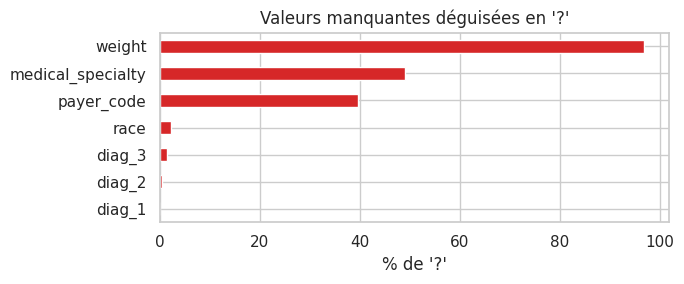

In [12]:
print("Valeurs NaN vues par pandas (isna) :", int(raw.isna().sum().sum()))

# (2) manquants déguisés : '?' (comptage et pourcentage par colonne)
n_q = (raw == "?").sum()
miss = pd.DataFrame({"nb de '?'": n_q, "% de '?'": (n_q/len(raw)*100).round(2)})
miss = miss[miss["nb de '?'"] > 0].sort_values("% de '?'", ascending=False)
print("\nColonnes avec des '?' :"); display(miss)
print("Colonnes sans aucun manquant :", int((n_q==0).sum()), "sur", raw.shape[1])

fig, ax = plt.subplots(figsize=(7,3))
miss["% de '?'"].plot.barh(ax=ax, color="tab:red"); ax.set_xlabel("% de '?'"); ax.invert_yaxis(); ax.set_title("Valeurs manquantes déguisées en '?'")
plt.tight_layout(); plt.show()

**Constat :**
- `isna()` renvoie **0** : à première vue, le fichier est complet. C'est **faux** : `pandas` ne reconnaît pas `"?"` comme manquant.
- En cherchant les `"?"`, on trouve **7 colonnes** concernées : `weight` (**96,9 %**, inexploitable), `medical_specialty` (**49 %**), `payer_code` (**40 %**), puis `race` (2,2 %), `diag_3` (1,4 %), `diag_2` (0,4 %) et `diag_1` (0,02 %).
- Les 43 autres colonnes n'ont aucun manquant.

### Les « faux manquants » cliniques
Les colonnes `A1Cresult` et `max_glu_serum` contiennent la valeur texte `"None"`. Ce n'est **pas** une donnée manquante au sens technique : cela signifie **« l'examen n'a pas été réalisé »**, ce qui est une information clinique.

In [13]:
for c in ["A1Cresult","max_glu_serum"]:
    print(c, raw[c].value_counts().to_dict())
raw["readmitted_30"] = (raw.readmitted=="<30").astype(int)
print("\nCible readmitted :", raw.readmitted.value_counts().to_dict())
print("Taux de réadmission < 30 j :", round(raw.readmitted_30.mean()*100,2), "%")
print("\nTaux de réadmission selon le résultat HbA1c :")
print((raw.groupby("A1Cresult").readmitted_30.mean()*100).round(1).to_string())

A1Cresult {'None': 84748, '>8': 8216, 'Norm': 4990, '>7': 3812}
max_glu_serum {'None': 96420, 'Norm': 2597, '>200': 1485, '>300': 1264}

Cible readmitted : {'NO': 54864, '>30': 35545, '<30': 11357}
Taux de réadmission < 30 j : 11.16 %

Taux de réadmission selon le résultat HbA1c :
A1Cresult
>7      10.0
>8       9.9
None    11.4
Norm     9.7


**Constat clé :** 83 % des séjours n'ont **pas** de mesure d'HbA1c. Garder la modalité `None` comme catégorie **« NotTested »** est plus honnête que de l'imputer ; l'absence de test est elle-même une information, que l'on réutilisera pour construire `clinical_inertia` (section 5).

### Structure des séjours : un patient, plusieurs lignes

In [14]:
vc = raw.patient_nbr.value_counts()
print("Patients uniques :", len(vc), "| séjours :", len(raw))
print("Part de patients avec plus d'un séjour :", round((vc>1).mean()*100,1), "% | max :", vc.max())
print("Doublons de lignes entières :", raw.duplicated().sum(), "| encounter_id dupliqués :", raw.encounter_id.duplicated().sum())

Patients uniques : 71518 | séjours : 101766
Part de patients avec plus d'un séjour : 23.5 % | max : 40
Doublons de lignes entières : 0 | encounter_id dupliqués : 0


**Constat important :** ~23 % des patients apparaissent plusieurs fois (jusqu'à 40 séjours). Cela a **une conséquence méthodologique majeure** : si on découpait train/test au hasard **ligne par ligne**, un même patient serait des deux côtés et le modèle « reconnaîtrait » ses habitudes. **On découpera donc par patient** (section 6).

### Colonnes constantes ou quasi constantes (médicaments)

In [15]:
drugs = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride','acetohexamide','glipizide','glyburide','tolbutamide',
         'pioglitazone','rosiglitazone','acarbose','miglitol','troglitazone','tolazamide','examide','citoglipton','insulin',
         'glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']
share_no = (raw[drugs]=="No").mean().sort_values(ascending=False)
print((share_no*100).round(2).to_string())

citoglipton                 100.00
examide                     100.00
acetohexamide               100.00
metformin-pioglitazone      100.00
glimepiride-pioglitazone    100.00
metformin-rosiglitazone     100.00
troglitazone                100.00
glipizide-metformin          99.99
tolbutamide                  99.98
miglitol                     99.96
tolazamide                   99.96
chlorpropamide               99.92
acarbose                     99.70
nateglinide                  99.31
glyburide-metformin          99.31
repaglinide                  98.49
glimepiride                  94.90
rosiglitazone                93.75
pioglitazone                 92.80
glyburide                    89.53
glipizide                    87.53
metformin                    80.36
insulin                      46.56


**Constat :** `examide` et `citoglipton` valent **toujours « No »** (variance nulle, aucune information) ; 6 autres molécules sont à 99,9 % « No » ou plus. Seules **`insulin`** (≈ 53 % de prescription) et **`metformin`** (≈ 20 %) sont fréquentes ; viennent ensuite glipizide (12 %), glyburide (10 %), pioglitazone (7 %), rosiglitazone (6 %) et glimepiride (5 %), les 12 autres étant sous 1,5 %.
**Choix :** garder `insulin` et `metformin` individuellement (les deux traitements de référence, les plus prescrits), et résumer **toutes** les molécules par deux compteurs (nombre utilisées / nombre modifiées), section 4.3. C'est un compromis : on perd le détail des molécules moins fréquentes, on gagne ~20 colonnes peu stables.

## 3. Data Exploration
Objectif : **comprendre les distributions, repérer les relations avec la cible et détecter les anomalies**, *avant* de décider quoi nettoyer. On explore les données **brutes** (hors transformation) ; le taux de base est de **11,2 %**.

### 3.1 La cible : un problème déséquilibré

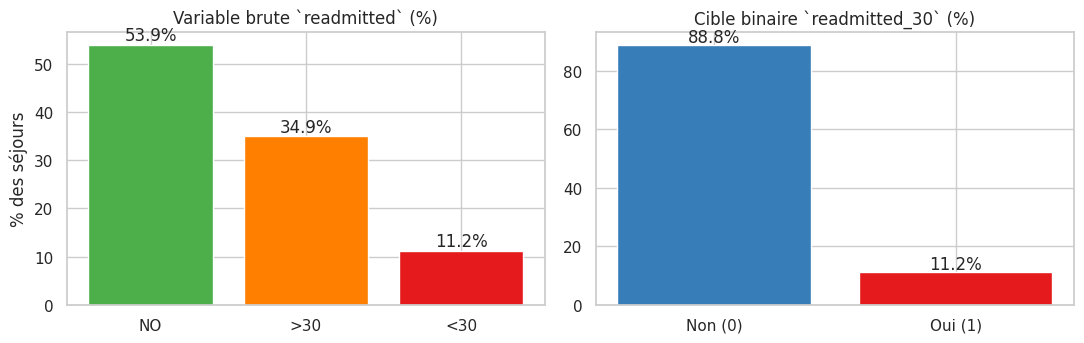

Un modèle qui répond toujours 'pas de réadmission' aurait 88.8 % d'accuracy : l'accuracy est donc une métrique inutile ici.


In [16]:
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
cnt = raw.readmitted.value_counts().reindex(["NO",">30","<30"])
ax[0].bar(cnt.index, cnt.values/len(raw)*100, color=["#4daf4a","#ff7f00","#e41a1c"]); ax[0].set(title="Variable brute `readmitted` (%)", ylabel="% des séjours")
for i,v in enumerate(cnt.values/len(raw)*100): ax[0].text(i, v+1, f"{v:.1f}%", ha="center")
b = raw.readmitted_30.value_counts(normalize=True).sort_index()*100
ax[1].bar(["Non (0)","Oui (1)"], b.values, color=["#377eb8","#e41a1c"]); ax[1].set(title="Cible binaire `readmitted_30` (%)")
for i,v in enumerate(b.values): ax[1].text(i, v+1, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.show()
print("Un modèle qui répond toujours 'pas de réadmission' aurait", round((1-raw.readmitted_30.mean())*100,1), "% d'accuracy : l'accuracy est donc une métrique inutile ici.")

**Constat :** 11,2 % de positifs. **Conséquence sur la méthode** : (1) on évaluera avec AUC / PR-AUC / recall à capacité donnée, pas l'accuracy ; (2) on traitera le déséquilibre par `class_weight` plutôt que par des patients synthétiques ; (3) on **stratifiera** le découpage train/test.

### 3.2 Distributions des variables numériques

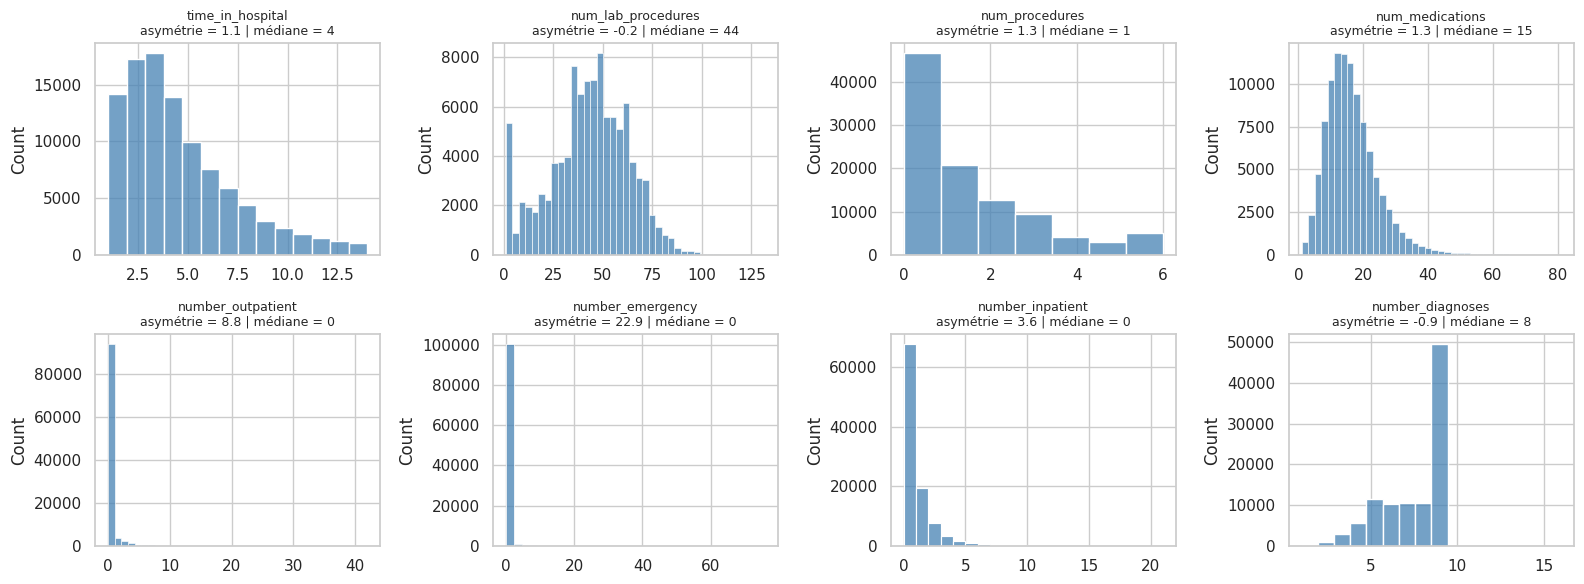

In [17]:
nums_e = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_outpatient','number_emergency','number_inpatient','number_diagnoses']
fig, ax = plt.subplots(2,4, figsize=(16,6))
for a,c in zip(ax.ravel(), nums_e):
    sns.histplot(raw[c], bins=min(40, raw[c].nunique()), ax=a, color="steelblue")
    a.set_title(f"{c}\nasymétrie = {raw[c].skew():.1f} | médiane = {raw[c].median():.0f}", fontsize=9); a.set_xlabel("")
plt.tight_layout(); plt.show()

**Constat :**
- **Fortement asymétriques à droite** : `number_emergency` (asymétrie ≈ 23), `number_outpatient` (≈ 9), `number_inpatient` (≈ 3,6). La très grande majorité des patients vaut **0** et quelques-uns ont des dizaines de passages.
- **Peu ou modérément asymétriques** : `num_lab_procedures` (−0,2, quasi symétrique), `time_in_hospital`, `num_procedures` et `num_medications` (≈ 1,1 à 1,3, queue à droite modérée) ; `number_diagnoses` (−0,9) a une queue à gauche.
- `number_diagnoses` a un **pic énorme à 9** (voir 3.6) : ce n'est pas une vraie distribution.
- `time_in_hospital` s'arrête **net à 14 jours** : la variable est *tronquée* (censurée) à 14.

**Implication :** on devra (1) plafonner les extrêmes, (2) appliquer `log1p` aux variables asymétriques, (3) standardiser, car l'ACP et K-Means sont sensibles à l'échelle et aux queues lourdes.

### 3.3 Distributions des variables catégorielles

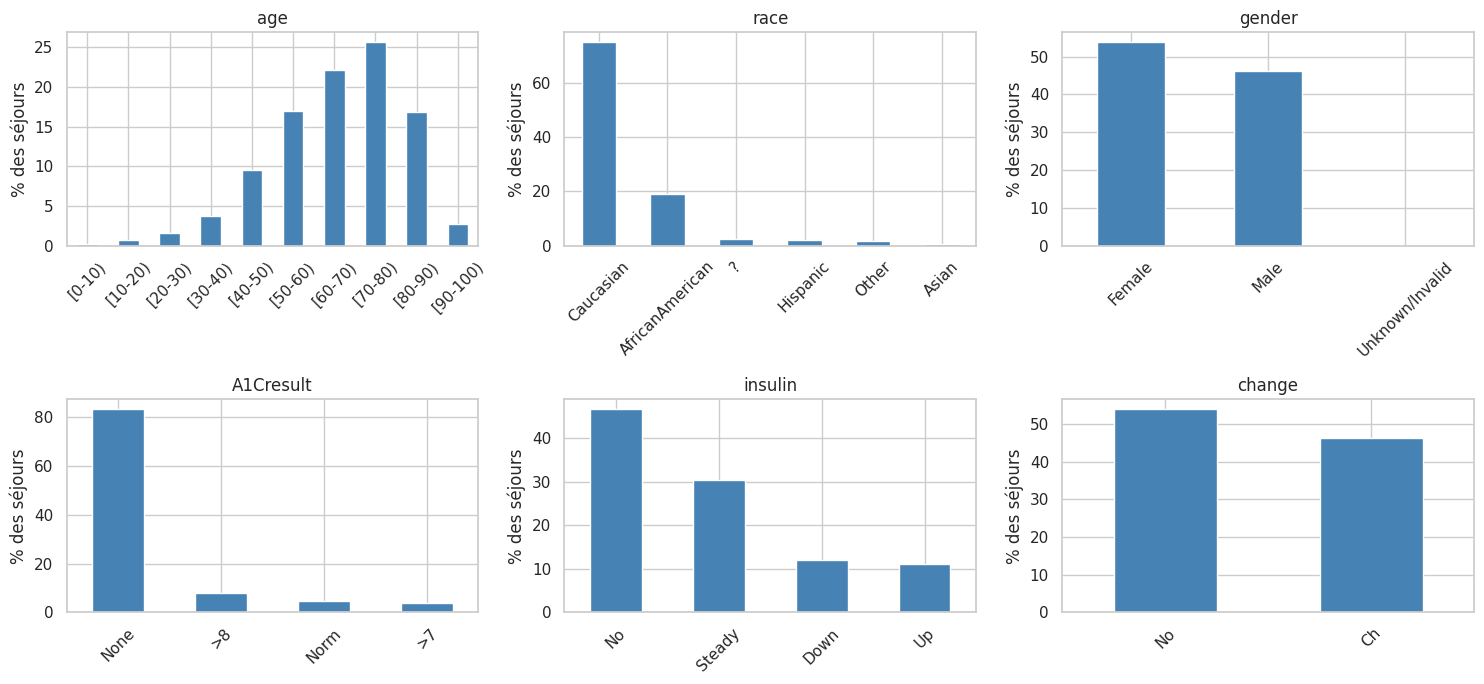

In [18]:
fig, ax = plt.subplots(2,3, figsize=(15,7))
for a,c in zip(ax.ravel(), ["age","race","gender","A1Cresult","insulin","change"]):
    vc = raw[c].value_counts(normalize=True).sort_index()*100 if c=="age" else raw[c].value_counts(normalize=True)*100
    vc.plot.bar(ax=a, color="steelblue", rot=45); a.set(title=c, ylabel="% des séjours", xlabel="")
plt.tight_layout(); plt.show()

**Constat :**
- **Âge** : population âgée (mode 70-80 ans, ≈ 26 %) ; les moins de 20 ans sont **rares** (852 séjours, 0,8 %).
- **Race** : ≈ 75 % *Caucasian*, ≈ 19 % *AfricanAmerican* ; les autres groupes sont petits (*Hispanic* 2 %, *Asian* 0,6 %). Cela limitera la **fiabilité de l'audit d'équité** pour ces groupes.
- **Genre** : équilibré (54 % F / 46 % M).
- **HbA1c** : 83 % **non testé** (`None`).
- **Insuline** : ≈ 47 % des séjours sans insuline, 30 % « Steady », le reste modifiée à la hausse ou à la baisse. `change` : 46 % des séjours ont un changement de traitement.

### 3.4 Relations avec la cible : quelles variables font varier le taux de réadmission ?

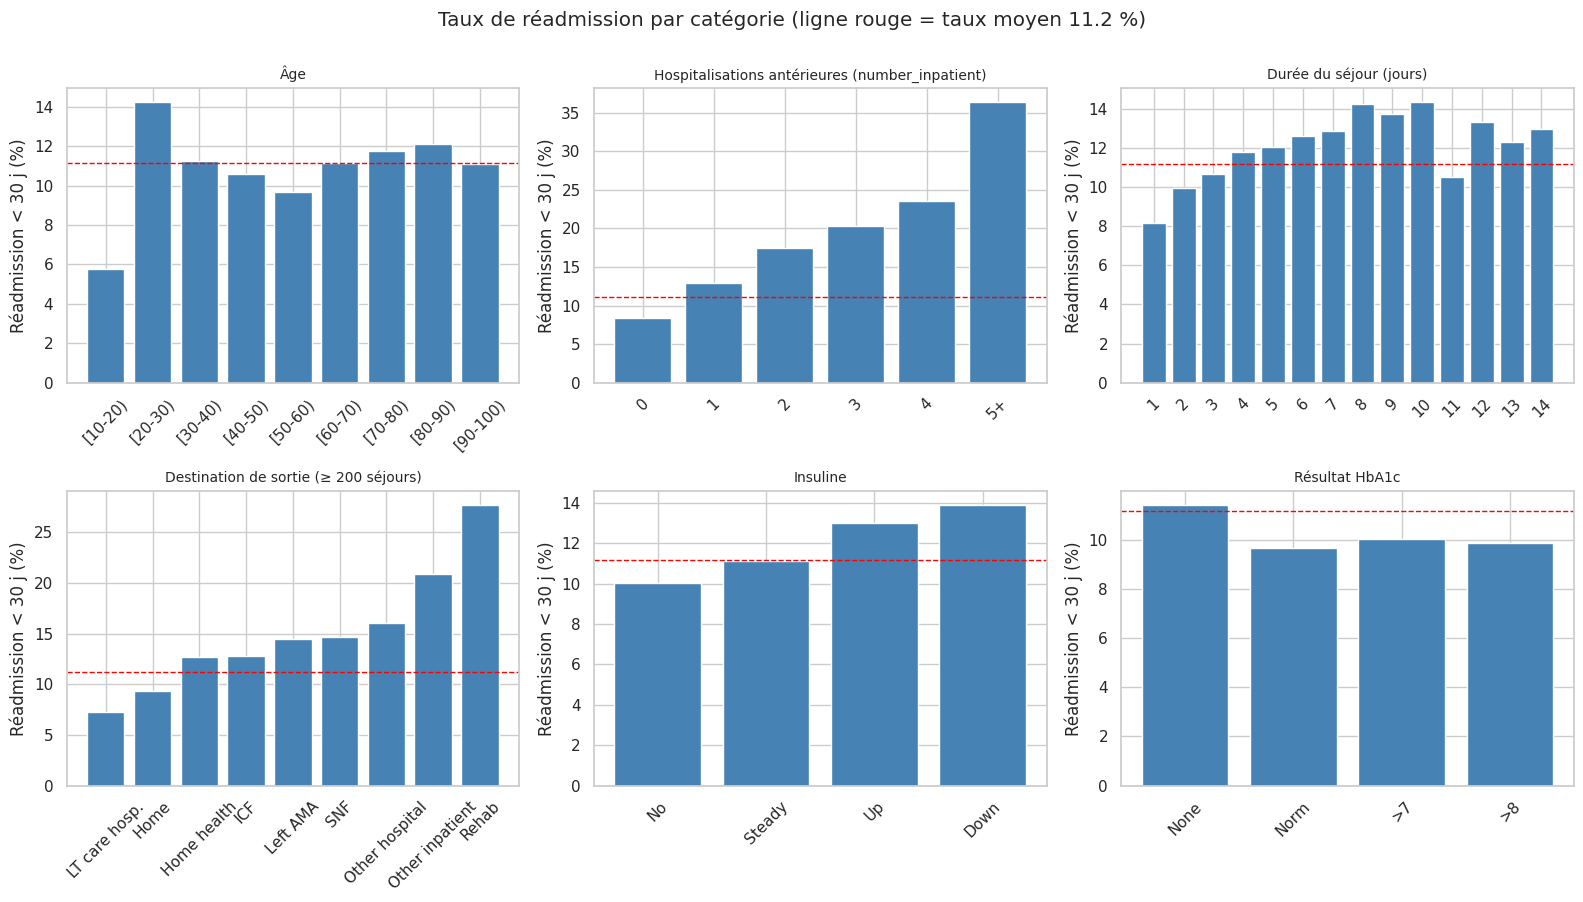

In [19]:
base = raw.readmitted_30.mean()*100
raw["inpatient_cap"] = raw.number_inpatient.clip(upper=5).map(lambda v: "5+" if v>=5 else str(int(v)))
dis_lab = {1:"Home",6:"Home health",3:"SNF",2:"Other hospital",5:"Other inpatient",22:"Rehab",4:"ICF",7:"Left AMA",23:"LT care hosp.",28:"Psychiatric"}
raw["dis_lab"] = raw.discharge_disposition_id.map(dis_lab)

def rate(col, order=None, minn=200):
    g = raw.groupby(col).readmitted_30.agg(["mean","size"]); g = g[g["size"]>=minn]
    g["mean"] *= 100
    return g.reindex(order) if order is not None else g

fig, ax = plt.subplots(2,3, figsize=(16,9))
panels = [("age",None,"Âge"),("inpatient_cap",["0","1","2","3","4","5+"],"Hospitalisations antérieures (number_inpatient)"),
          ("time_in_hospital",None,"Durée du séjour (jours)"),("dis_lab",None,"Destination de sortie (≥ 200 séjours)"),
          ("insulin",["No","Steady","Up","Down"],"Insuline"),("A1Cresult",["None","Norm",">7",">8"],"Résultat HbA1c")]
for a,(col,order,title) in zip(ax.ravel(), panels):
    g = rate(col, order)
    if col=="dis_lab": g = g.sort_values("mean")
    a.bar(g.index.astype(str), g["mean"], color="steelblue"); a.axhline(base, ls="--", c="red", lw=1)
    a.set_title(title, fontsize=10); a.set_ylabel("Réadmission < 30 j (%)"); a.tick_params(axis="x", rotation=45)
fig.suptitle(f"Taux de réadmission par catégorie (ligne rouge = taux moyen {base:.1f} %)", y=1.0)
plt.tight_layout(); plt.show()

**Constats, du plus fort au plus faible :**
1. **Hospitalisations antérieures : de loin le signal le plus net.** Le taux monte de façon **régulière** : ≈ 8 % (0), 13 % (1), 17 % (2), 20 % (3), 24 % (4) et **36 % à 5 et plus** (4 fois le taux des patients sans hospitalisation antérieure).
2. **Destination de sortie** : les sorties vers une structure de soins (réadaptation, autre hôpital) ont des taux nettement supérieurs au retour à domicile.
3. **Durée du séjour** : le taux monte de ≈ 8 % (1 jour) à ≈ 14 % (8-10 jours), puis se stabilise. Effet réel mais modéré.
4. **Âge** : relation **non monotone** : un taux élevé à 20-30 ans (≈ 14 %, mais seulement 1 657 séjours), un creux à 50-60 ans (≈ 9,7 %), puis une remontée avec l'âge. Pas de simple « plus on est âgé, plus on revient ».
5. **Insuline** : le taux est plus élevé quand la dose **change** (hausse ou baisse : ≈ 13-14 %) que sans insuline (10 %). Un changement de dose est plutôt un marqueur d'**instabilité**.
6. **HbA1c** : presque **aucune relation** avec le résultat (≈ 10 % que la valeur soit normale, > 7 ou > 8 ; les patients non testés sont à 11,4 %). Surprise : l'indicateur emblématique du diabète n'est pas discriminant ici.

**Mise en garde statistique :** ces taux sont des associations brutes, non ajustées. Les patients à beaucoup d'hospitalisations sont aussi souvent plus âgés, plus complexes, etc.

### 3.5 Quelles variables numériques séparent le mieux réadmis / non réadmis ?
On compare les moyennes avec une **taille d'effet standardisée** (d de Cohen : écart des moyennes / écart-type global). Elle est comparable d'une variable à l'autre, contrairement à l'écart brut.

,moy. non réadmis,moy. réadmis,d de Cohen
variable,,,
number_inpatient,0.562,1.224,0.524
number_emergency,0.178,0.357,0.193
number_diagnoses,7.389,7.693,0.157
time_in_hospital,4.349,4.768,0.140
num_medications,15.911,16.903,0.122
num_lab_procedures,42.954,44.226,0.065
number_outpatient,0.361,0.437,0.060
num_procedures,1.347,1.281,-0.039


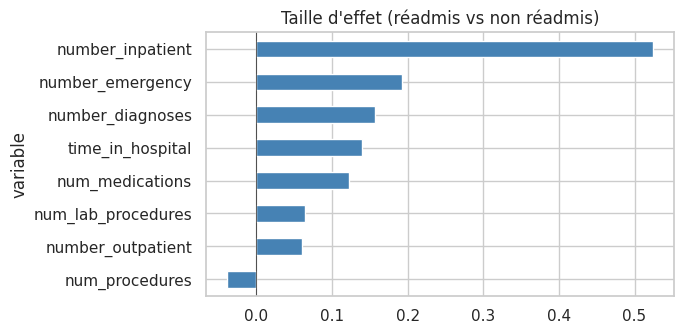

In [20]:
rows=[]
for c in nums_e:
    a, b_ = raw.loc[raw.readmitted_30==0,c], raw.loc[raw.readmitted_30==1,c]
    d = (b_.mean()-a.mean())/raw[c].std()
    rows.append((c, a.mean(), b_.mean(), d))
eff = pd.DataFrame(rows, columns=["variable","moy. non réadmis","moy. réadmis","d de Cohen"]).set_index("variable").sort_values("d de Cohen", key=abs, ascending=False).round(3)
display(eff)
eff["d de Cohen"].iloc[::-1].plot.barh(figsize=(7,3.5), color="steelblue", title="Taille d'effet (réadmis vs non réadmis)")
plt.axvline(0,c="k",lw=.5); plt.tight_layout(); plt.show()

**Constat :** `number_inpatient` domine (d ≈ **0,52**, un effet « moyen » par convention). Les autres effets sont **petits** (par convention, d < 0,2) : `number_emergency` (0,19), `number_diagnoses` (0,16), `time_in_hospital` (0,14), `num_medications` (0,12), puis `num_lab_procedures` et `number_outpatient` (≈ 0,06). C'est cohérent avec le déséquilibre et annonce un **pouvoir prédictif limité**.
Le nombre de procédures est même *légèrement plus bas* chez les réadmis (d = −0,04) : une intervention planifiée est un peu moins souvent suivie d'un retour, mais l'effet est négligeable.

### 3.6 Anomalies et problèmes de qualité détectés

In [21]:
dead = [11,13,14,19,20,21]
anom = pd.DataFrame([
 ("Valeurs manquantes codées '?' (weight)",            int((raw.weight=="?").sum()),                         "inexploitable (97 %)"),
 ("Valeurs manquantes codées '?' (medical_specialty)",  int((raw.medical_specialty=="?").sum()),              "marquer 'Missing'"),
 ("Valeurs manquantes codées '?' (payer_code)",         int((raw.payer_code=="?").sum()),                     "colonne retirée"),
 ("Patients décédés / en hospice (ne peuvent pas être réadmis)", int(raw.discharge_disposition_id.isin(dead).sum()), "exclure du modèle, garder au tableau de bord"),
 ("Genre invalide",                                     int((raw.gender=="Unknown/Invalid").sum()),            "exclure"),
 ("Type d'admission 'Not available / NULL / Not mapped'", int(raw.admission_type_id.isin([5,6,8]).sum()),      "regrouper 'Other / unknown'"),
 ("number_diagnoses = 9 (pic suspect, plafond de saisie ?)", int((raw.number_diagnoses==9).sum()),             "garder, signaler la limite"),
 ("time_in_hospital = 14 (variable tronquée)",          int((raw.time_in_hospital==14).sum()),                 "garder, plafonnement"),
 ("Séjours de patients < 20 ans",                       int(raw.age.isin(['[0-10)','[10-20)']).sum()),         "garder (diabète type 1), groupes petits"),
 ("Diagnostics de type V/E (codes spéciaux ICD-9)",     int(raw.diag_1.str.startswith(('V','E')).sum()),       "groupe 'Other'"),
 ("Médicaments constants (100 % 'No')",                 int(((raw[drugs]=='No').all()).sum()),                 "retirer examide, citoglipton"),
 ("Patients avec > 10 séjours",                         int((raw.patient_nbr.value_counts()>10).sum()),        "découpage par patient obligatoire"),
 ("number_emergency maximum",                           int(raw.number_emergency.max()),                       "vraie observation extrême, plafonner"),
], columns=["anomalie","nombre","traitement prévu"])
anom

,anomalie,nombre,traitement prévu
0,Valeurs manquantes codées '?' (weight),98569,inexploitable (97 %)
1,Valeurs manquantes codées '?' (medical_specialty),49949,marquer 'Missing'
2,Valeurs manquantes codées '?' (payer_code),40256,colonne retirée
3,Patients décédés / en hospice (ne peuvent pas ...,2423,"exclure du modèle, garder au tableau de bord"
4,Genre invalide,3,exclure
5,Type d'admission 'Not available / NULL / Not m...,10396,regrouper 'Other / unknown'
6,"number_diagnoses = 9 (pic suspect, plafond de ...",49474,"garder, signaler la limite"
7,time_in_hospital = 14 (variable tronquée),1042,"garder, plafonnement"
8,Séjours de patients < 20 ans,852,"garder (diabète type 1), groupes petits"
9,Diagnostics de type V/E (codes spéciaux ICD-9),1645,groupe 'Other'


**Bilan de l'exploration : ce que l'on retient pour la préparation**

| Ce que montre l'exploration | Conséquence dans la préparation (section 4) |
|---|---|
| 11 % de positifs | découpage stratifié ; métriques adaptées ; `class_weight` |
| compteurs très asymétriques, valeurs extrêmes réelles | plafonner à 1 %-99 % (ne rien supprimer) puis `log1p` |
| `?` et `None` : deux sens différents | `"?"` = manquant (à marquer) ; `"None"` = « examen non réalisé » (vraie modalité) |
| décès / hospice (cible = 0 par construction) | catégorie dédiée `Deceased / hospice`, puis **exclus de la modélisation** (conservés dans `clean` et le tableau de bord), effet mesuré en 7.5 |
| genres invalides (3 lignes) | exclusion |
| patients répétés (23 % ont plusieurs séjours) | découpage par **patient** |
| codes administratifs, diagnostics à des centaines de modalités | regroupements lisibles (ICD-9 en 9 groupes) |
| 23 médicaments quasi constants | résumer par deux compteurs |
| signal fort : historique d'hospitalisations ; HbA1c non discriminante | créer des variables d'historique ; tester `clinical_inertia` |

## 4. Data Preparation
Plan (suit le cours *Chapter 1* d'ESPRIT) : **4.1 Data Cleaning → 4.2 Feature Engineering → 4.3 Découpage train/test → 4.4 Feature Selection → 4.5 Data Transforms → 4.6 Réduction de dimension (ACP) → 4.7 Sauvegarde → 4.8 Résumé.**

## 4.1 Data Preparation — Étape 1 : Data Cleaning
Le cours liste : *définir ce qu'est une donnée normale, supprimer doublons et colonnes redondantes ou non pertinentes, identifier les outliers, traiter les valeurs manquantes.*

### 4.1.1 Définir la population « normale » : que faire des patients décédés ou en hospice ?
**Choix en deux temps : on les IDENTIFIE et on les CONSERVE dans le fichier nettoyé et le tableau de bord, mais on les EXCLUT de la modélisation** (segmentation, classification, tests). Ce sont les motifs de sortie 11, 13, 14, 19, 20, 21 d'après `IDS_mapping.csv`. Ils sont identifiés par une catégorie dédiée `Deceased / hospice` dans `discharge_dest` (section 4.2.2) ; la mise de côté se fait en 4.3, avant tout découpage et toute statistique apprise.

**Raisons :**
- **Un patient décédé ne peut pas être réadmis** : sa cible vaut 0 *mécaniquement*, quelles que soient ses autres variables. Il n'y a donc **rien à apprendre** sur lui, et ce n'est pas la question posée : *« parmi les patients vivants qui sortent, lesquels risquent de revenir ? »*.
- **Les garder fausserait le modèle** : il apprendrait la règle « décès → pas de réadmission », qui pèserait fortement dans l'importance des variables (ce n'est pas un signal médical) et **gonflerait légèrement** les métriques.
- **Mais ce sont des séjours réels** : on les garde dans `diabetes_clean.csv` (colonne `split = excluded`) et dans le **tableau de bord** (BO5), qui doit refléter toute l'activité de l'hôpital.

**Vérification :** la section 7.5 refait le pipeline *avec* ces séjours et compare les performances, pour montrer que ce choix ne change pas les conclusions.

On retire aussi les 3 lignes dont le genre est `Unknown/Invalid` (impossible à interpréter, négligeable).

In [22]:
ids = pd.read_csv("IDS_mapping.csv", header=None, skip_blank_lines=False)
dead = [11,13,14,19,20,21]
is_dead = raw.discharge_disposition_id.isin(dead)
print("Séjours décès/hospice (exclus de la modélisation, conservés dans clean) :", is_dead.sum(), f"({is_dead.mean()*100:.1f} % des séjours)")
print("Taux de réadmission < 30 j : décès/hospice =", round(raw.loc[is_dead,"readmitted_30"].mean()*100,2), "% | autres =", round(raw.loc[~is_dead,"readmitted_30"].mean()*100,2), "%")
mask = (raw.gender=="Unknown/Invalid")
print("Lignes retirées (genre invalide) :", mask.sum())
df = raw.loc[~mask].copy()
print("Population retenue :", df.shape[0], "séjours")

Séjours décès/hospice (exclus de la modélisation, conservés dans clean) : 2423 (2.4 % des séjours)
Taux de réadmission < 30 j : décès/hospice = 1.77 % | autres = 11.39 %
Lignes retirées (genre invalide) : 3
Population retenue : 101763 séjours


**Constat :** seules **3 lignes** sont retirées. Les décès/hospice (2 423 séjours, 2,4 %) ont un taux de réadmission de **1,8 %** (contre 11,4 % pour les autres) : ils sont donc très différents du reste, ce qui justifie de les identifier par une catégorie dédiée (4.2.2), puis de les exclure de la modélisation (4.3). L'écart n'est pas nul (1,8 % et non 0 %) : certains patients en hospice à domicile (codes 13, 14) peuvent encore être réhospitalisés.

### 4.1.2 Doublons (échantillons redondants)
Le cours : `duplicated()` / `drop_duplicates()`. Résultat de la section 2 : **aucun doublon** (ni ligne entière, ni `encounter_id`). Rien à supprimer.
*Attention : on **ne** supprime **pas** les patients répétés : ce sont des séjours distincts et réels.*

### 4.1.3 Colonnes redondantes ou non pertinentes

In [23]:
drop_cols = ["weight","payer_code","examide","citoglipton"]
print({c: f"{round((raw[c]=='?').mean()*100,1)}% manquant" for c in ["weight","payer_code"]})
df = df.drop(columns=drop_cols)
print("Colonnes restantes :", df.shape[1])

{'weight': '96.9% manquant', 'payer_code': '39.6% manquant'}
Colonnes restantes : 49


| Colonne retirée | Raison |
|---|---|
| `weight` | 97 % manquant : imputer serait inventer |
| `payer_code` | 40 % manquant **et** variable administrative (assurance), sans lien clinique, risque d'introduire un biais socio-économique non voulu |
| `examide`, `citoglipton` | variance nulle (toujours « No ») |

On retire aussi plus tard `encounter_id` (identifiant, pas une variable prédictive) du jeu de modélisation, mais on le garde dans le fichier « clean » pour la traçabilité.

### 4.1.4 Valeurs manquantes : *marquer* plutôt qu'imputer
Le cours présente deux familles : **Mark** et **Impute** (moyenne, médiane, plus fréquent, constante...).

| Colonne | Taux | Choix | Pourquoi |
|---|---|---|---|
| `medical_specialty` | 49 % | catégorie **`Missing`** | à 49 % imputer par le mode créerait de fausses « Médecine interne » ; l'absence est peut-être informative |
| `race` | 2 % | catégorie **`Unknown`** | variable sensible : on ne devine pas la race d'un patient. On garde `Unknown` visible pour **auditer l'équité** |
| `diag_1/2/3` | < 2 % | groupe **`Unknown`** | un diagnostic secondaire absent = *pas de 2ᵉ/3ᵉ diagnostic*, pas une erreur |
| `A1Cresult`, `max_glu_serum` | 83 %/95 % | **`NotTested`** | « faux manquant » : examen non fait |

**Pourquoi pas l'imputation statistique ?** Une imputation par la médiane ou le mode suppose que la donnée manque *au hasard*. Ici, l'absence **dépend du patient** (un examen non prescrit n'est pas un oubli de saisie). Marquer préserve cette information.

In [24]:
df["race"] = df.race.replace("?", "Unknown")
df["medical_specialty"] = df.medical_specialty.replace("?", "Missing")
print("Manquants restants hors diagnostics :", int((df.drop(columns=['diag_1','diag_2','diag_3'])=="?").sum().sum()))

Manquants restants hors diagnostics : 0


### 4.1.5 Outliers : détecter maintenant, traiter après le découpage
Le cours : *détecter par boxplot / histogramme, puis supprimer, plafonner (cap) ou remplacer*.

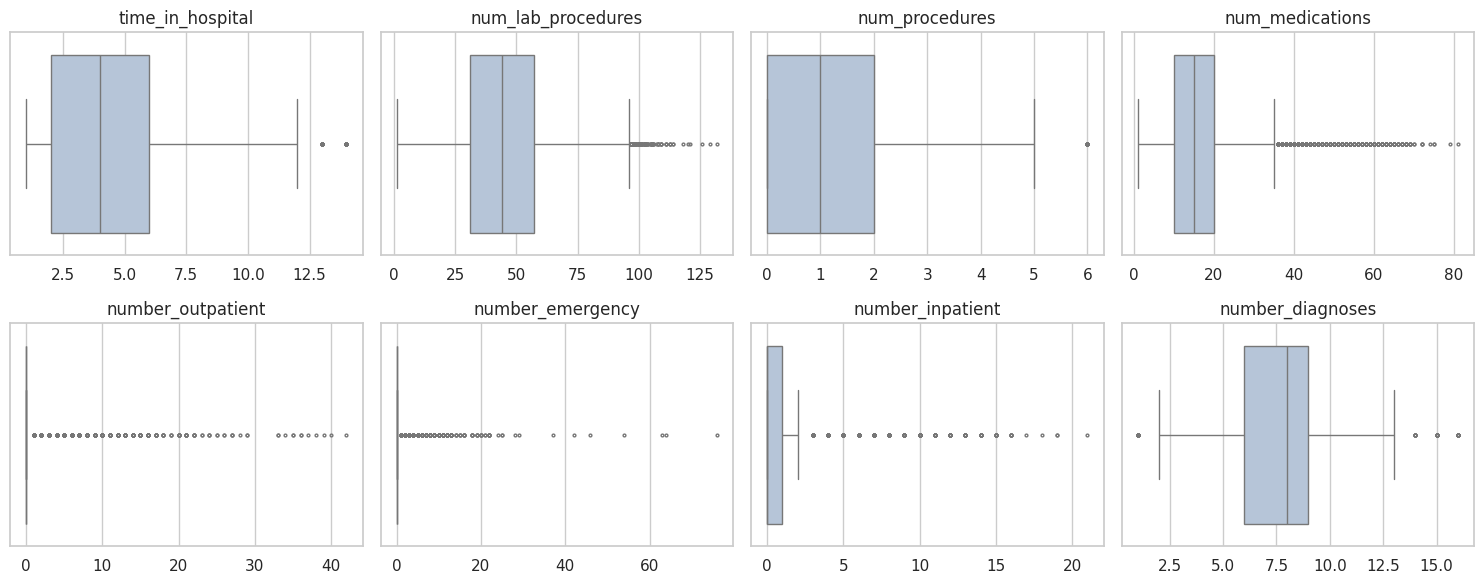

,max,P99,% hors règle IQR
variable,,,
time_in_hospital,14,14.0,2.2
num_lab_procedures,132,85.0,0.1
num_procedures,6,6.0,4.9
num_medications,81,43.0,2.5
number_outpatient,42,5.0,16.4
number_emergency,76,3.0,11.2
number_inpatient,21,6.0,6.9
number_diagnoses,16,9.0,0.3


In [26]:
nums = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_outpatient','number_emergency','number_inpatient','number_diagnoses']
fig, ax = plt.subplots(2,4, figsize=(15,6))
for a,c in zip(ax.ravel(), nums):
    sns.boxplot(x=df[c], ax=a, color="lightsteelblue", fliersize=2); a.set_title(c); a.set_xlabel("")
plt.tight_layout(); plt.show()

rows=[]
for c in nums:
    q1,q3 = df[c].quantile([.25,.75]); iqr=q3-q1
    out = ((df[c]>q3+1.5*iqr)|(df[c]<q1-1.5*iqr)).mean()*100
    rows.append((c, df[c].max(), df[c].quantile(.99), round(out,1)))
pd.DataFrame(rows, columns=["variable","max","P99","% hors règle IQR"]).set_index("variable")

**Constat :** les distributions sont très **asymétriques à droite** (beaucoup de petites valeurs, quelques très grandes). Exemples : `number_emergency` va jusqu'à 76 alors que 99 % des patients sont à ≤ 3 environ ; `number_outpatient` jusqu'à 42.

**Ces valeurs extrêmes sont-elles des erreurs ?** Non : un patient qui a eu 21 hospitalisations dans l'année est **réel et cliniquement important** (c'est précisément le « revenant »). Le cours distingue *erreur de mesure*, *corruption* et *vraie observation extrême* ; ici ce sont des vraies observations.

**Décision :**
- **On ne supprime aucune ligne** : supprimer les cas extrêmes retirerait justement les patients les plus à risque.
- **On plafonne (winsorisation) aux percentiles 1 % / 99 %**, pour empêcher quelques valeurs de dominer la standardisation et l'ACP.
- **Les seuils sont calculés sur le train uniquement** (section 4.5) pour éviter la fuite.
- La règle IQR de Tukey est jugée **trop agressive** ici : avec des distributions très asymétriques et beaucoup de zéros (Q1 = Q3 = 0), elle déclare « aberrant » **16,4 %** des patients pour `number_outpatient` et **11 %** pour `number_emergency`, alors qu'il s'agit de patients simplement fréquemment suivis.

## 4.2 Étape 2 : Feature Engineering (créer des variables)
Le cours : *« deriving new variables from available data »* (somme, quotient, regroupement…). On le fait **avant** la sélection de variables car certaines variables créées remplacent des variables brutes.

### 4.2.1 Regrouper les codes diagnostics (ICD-9) : 700+ codes → 9 groupes
`diag_1/2/3` contiennent des centaines de codes (ex. `250.83`, `414`, `428`). En one-hot cela créerait des centaines de colonnes quasi vides. On regroupe selon les **chapitres ICD-9** (convention standard de la littérature sur ce jeu de données).

In [27]:
def icd_group(code):
    if code == "?" or pd.isna(code): return "Unknown"
    if str(code).startswith(("V","E")): return "Other"
    v = float(code)
    if 250 <= v < 251: return "Diabetes"
    if 390 <= v <= 459 or v == 785: return "Circulatory"
    if 460 <= v <= 519 or v == 786: return "Respiratory"
    if 520 <= v <= 579 or v == 787: return "Digestive"
    if 800 <= v <= 999: return "Injury"
    if 710 <= v <= 739: return "Musculoskeletal"
    if 580 <= v <= 629 or v == 788: return "Genitourinary"
    if 140 <= v <= 239: return "Neoplasms"
    return "Other"

for k in (1,2,3):
    df[f"diag{k}_group"] = df[f"diag_{k}"].map(icd_group)
print(df.diag1_group.value_counts().to_dict())

{'Circulatory': 30436, 'Other': 18172, 'Respiratory': 14423, 'Digestive': 9475, 'Diabetes': 8757, 'Injury': 6972, 'Genitourinary': 5117, 'Musculoskeletal': 4957, 'Neoplasms': 3433, 'Unknown': 21}


**Remarque clinique :** le groupe `Diabetes` n'est que la **5ᵉ cause principale** d'hospitalisation ici (8,7 % des séjours, derrière circulatoire, « autre », respiratoire et digestif) : la plupart des patients sont hospitalisés pour **autre chose** (circulatoire, respiratoire…) tout en étant diabétiques. Cela justifie de ne pas restreindre l'analyse aux séjours « pour diabète ».

### 4.2.2 Regrouper les modalités administratives (identifiants → catégories lisibles)
`admission_type_id`, `admission_source_id`, `discharge_disposition_id` sont des **codes** (1, 2, 3…) : les traiter comme des nombres serait faux (le code 7 n'est pas « plus grand » que 1). On les remplace par des **catégories** à l'aide de `IDS_mapping.csv`, en regroupant les modalités rares ou équivalentes.

In [28]:
adm_type = {1:"Emergency",7:"Emergency",2:"Urgent",3:"Elective"}                   # 4,5,6,8 -> Other / unknown
adm_src  = {1:"Referral",2:"Referral",3:"Referral",
            4:"Transfer",5:"Transfer",6:"Transfer",10:"Transfer",22:"Transfer",25:"Transfer",26:"Transfer",
            7:"Emergency room"}                                                      # reste -> Other / unknown
dis = {1:"Home", 6:"Home health", 8:"Home health", 3:"Nursing / long-term care", 4:"Nursing / long-term care",
       23:"Nursing / long-term care", 24:"Nursing / long-term care", 22:"Rehab", 7:"Left AMA",
       2:"Hospital transfer / other", 5:"Hospital transfer / other", 9:"Hospital transfer / other", 10:"Hospital transfer / other",
       12:"Hospital transfer / other", 15:"Hospital transfer / other", 16:"Hospital transfer / other", 17:"Hospital transfer / other",
       27:"Hospital transfer / other", 28:"Hospital transfer / other",
       11:"Deceased / hospice", 13:"Deceased / hospice", 14:"Deceased / hospice", 19:"Deceased / hospice", 20:"Deceased / hospice", 21:"Deceased / hospice"}   # 18,25,26,... -> Other / unknown
df["admission_type"]   = df.admission_type_id.map(adm_type).fillna("Other / unknown")
df["admission_source"] = df.admission_source_id.map(adm_src).fillna("Other / unknown")
df["discharge_dest"]   = df.discharge_disposition_id.map(dis).fillna("Other / unknown")
print(df.discharge_dest.value_counts().to_dict())

{'Home': 60232, 'Nursing / long-term care': 15229, 'Home health': 13010, 'Other / unknown': 4680, 'Hospital transfer / other': 3574, 'Deceased / hospice': 2423, 'Rehab': 1992, 'Left AMA': 623}


**Choix de regroupement pour `discharge_dest` :** on isole d'abord `Deceased / hospice` (pour pouvoir les mettre de côté, voir 4.1.1 et 4.3), puis on sépare ce qui a un **sens clinique différent** pour le risque : `Home` (retour sans aide), `Home health` (retour avec soins à domicile), `Nursing / long-term care`, `Rehab`, `Hospital transfer`. On garde `Left AMA` (sortie contre avis médical) à part car c'est un signal de risque connu.

### 4.2.3 Variables d'historique, d'intensité et de traitement

In [29]:
age_mid = {"[0-10)":5,"[10-20)":15,"[20-30)":25,"[30-40)":35,"[40-50)":45,"[50-60)":55,"[60-70)":65,"[70-80)":75,"[80-90)":85,"[90-100)":95}
df["age_mid"] = df.age.map(age_mid)

# Historique de recours aux soins
df["total_prior_visits"] = df.number_outpatient + df.number_emergency + df.number_inpatient
df["acute_prior_visits"] = df.number_emergency + df.number_inpatient

# Intensité de la prise en charge, normalisée par la durée du séjour
df["meds_per_day"] = df.num_medications / df.time_in_hospital
df["labs_per_day"] = df.num_lab_procedures / df.time_in_hospital

# Complexité diagnostique
grp = df[["diag1_group","diag2_group","diag3_group"]]
df["n_dx_groups"]     = grp.apply(lambda r: len({g for g in r if g!="Unknown"}), axis=1)
df["any_diabetes_dx"] = (grp=="Diabetes").any(axis=1).astype(int)

# Traitement : on résume 23 molécules par 2 compteurs
drugs_kept = [d for d in drugs if d in df.columns]          # 21 molécules (examide et citoglipton déjà retirées)
df["n_meds_used"]    = (df[drugs_kept]!="No").sum(axis=1)
df["n_meds_changed"] = df[drugs_kept].isin(["Up","Down"]).sum(axis=1)
df["change_flag"]       = (df.change=="Ch").astype(int)
df["diabetesMed_flag"]  = (df.diabetesMed=="Yes").astype(int)

# Tests : 'None' = non réalisé
df["A1C_status"] = df.A1Cresult.replace("None","NotTested")
df["glu_status"] = df.max_glu_serum.replace("None","NotTested")

# Inertie clinique : HbA1c élevée MAIS traitement non modifié
df["clinical_inertia"] = (df.A1C_status.isin([">7",">8"]) & (df.change_flag==0)).astype(int)
print(df[["age_mid","total_prior_visits","meds_per_day","n_dx_groups","n_meds_used","n_meds_changed","clinical_inertia"]].describe().round(2).T[["mean","std","min","max"]])

                     mean    std   min   max
age_mid             65.97  15.94  5.00  95.0
total_prior_visits   1.20   2.29  0.00  80.0
meds_per_day         5.07   3.83  0.08  42.0
n_dx_groups          2.31   0.65  0.00   3.0
n_meds_used          1.18   0.92  0.00   6.0
n_meds_changed       0.29   0.49  0.00   4.0
clinical_inertia     0.05   0.21  0.00   1.0


| Variable créée | Formule | Pourquoi |
|---|---|---|
| `age_mid` | milieu de la tranche d'âge | l'âge est **ordinal** (10-20 < 20-30…) : on le convertit en nombre plutôt qu'en 10 colonnes one-hot, ce qui conserve l'ordre et économise des dimensions |
| `total_prior_visits` | consultations + urgences + hospitalisations antérieures | résume le recours aux soins (le « revenant ») |
| `acute_prior_visits` | urgences + hospitalisations | recours **aigu** (la consultation externe est moins grave) |
| `meds_per_day`, `labs_per_day` | actes ÷ durée | un séjour de 10 jours avec 20 médicaments n'a pas la même intensité qu'un séjour de 1 jour avec 20 médicaments |
| `n_dx_groups`, `any_diabetes_dx` | nb de groupes de diagnostics, présence d'un diagnostic diabète | **comorbidité** |
| `n_meds_used`, `n_meds_changed` | nombre de médicaments prescrits / modifiés (Up ou Down) | remplace 23 colonnes quasi vides |
| `clinical_inertia` | HbA1c > 7 **et** traitement inchangé | indicateur de **non-adaptation** thérapeutique face à un diabète mal contrôlé : notre variable la plus « médicale » |

**Idée originale (« out of the box ») :** `clinical_inertia` n'existe pas dans les données brutes. Elle traduit en une colonne un concept médical connu (*inertie thérapeutique*) en croisant deux colonnes (HbA1c + changement de traitement).

In [30]:
print("Part de séjours en 'inertie clinique' :", round(df.clinical_inertia.mean()*100,2), "%")
print("Réadmission 30 j  | inertie=1 :", round(df.loc[df.clinical_inertia==1,'readmitted_30'].mean()*100,2), "%  | inertie=0 :", round(df.loc[df.clinical_inertia==0,'readmitted_30'].mean()*100,2), "%")

Part de séjours en 'inertie clinique' : 4.66 %
Réadmission 30 j  | inertie=1 : 9.38 %  | inertie=0 : 11.25 %


**Résultat à lire avec honnêteté :** seuls **4,7 %** des séjours sont concernés, et leur taux de réadmission est **9,4 %**, c'est-à-dire **légèrement plus bas** que les 11,3 % des autres. L'hypothèse « inertie = risque plus élevé » n'est donc **pas confirmée** par ce chiffre brut. Une explication possible (non testée ici) est que ces patients, dont le traitement n'est pas modifié, sont moins instables à la sortie. On garde la variable car elle est interprétable et n'a pas de coût, mais on **ne la présentera pas** comme un facteur de risque. C'est un bon exemple de *résultat négatif* à rapporter plutôt qu'à cacher.

## 4.3 Mise de côté des décès / hospice, puis découpage train / test par patient (avant toute statistique apprise)
**Étape préalable :** on met de côté les séjours décès / hospice (`dead_all`). Ils ne participent ni au découpage, ni à l'ACP, ni aux modèles ; on les retrouvera dans le tableau de bord (7.3.1) et l'analyse de sensibilité (7.5).

**Ensuite le découpage :**
**Choix :** `StratifiedGroupKFold` (5 plis, on prend le 1ᵉʳ pli comme test = 20 %), avec `groups = patient_nbr` et stratification sur `readmitted_30`.
- **Group :** un patient entier va soit en train soit en test (pas de fuite entre séjours d'un même patient).
- **Stratified :** le taux de réadmission reste ≈ 11,4 % des deux côtés (population de modélisation : patients vivants, contre 11,2 % sur l'ensemble des séjours) (sans stratification, avec seulement 11 % de positifs, le test pourrait être très différent du train).

In [31]:
from sklearn.model_selection import StratifiedGroupKFold
dead_mask = df.discharge_dest == "Deceased / hospice"
dead_all = df[dead_mask].copy()                 # mis de côté : tableau de bord (7.3.1) et sensibilité (7.5)
dead_all["split"] = "excluded"
df = df[~dead_mask].reset_index(drop=True)      # population de modélisation (patients vivants à la sortie)
print("Mis de côté (décès / hospice) :", len(dead_all), "| population de modélisation :", len(df))
sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RS)
tr_idx, te_idx = next(iter(sgk.split(df, df.readmitted_30, df.patient_nbr)))
df["split"] = "train"; df.loc[te_idx, "split"] = "test"
print(df.split.value_counts().to_dict())
print("Taux de réadmission :", (df.groupby("split").readmitted_30.mean()*100).round(2).to_dict())
print("Patients partagés train/test :", len(set(df.patient_nbr[df.split=='train']) & set(df.patient_nbr[df.split=='test'])))

Mis de côté (décès / hospice) : 2423 | population de modélisation : 99340
{'train': 79309, 'test': 20031}
Taux de réadmission : {'test': 11.58, 'train': 11.34}
Patients partagés train/test : 0


## 4.4 Étape 3 : Feature Selection
Le cours distingue les méthodes **Filter** (score statistique par variable), **Wrapper** (sélection itérative avec un modèle, ex. RFE) et **Intrinsic** (arbres). Ici on fait de la **sélection supervisée de type filtre + analyse de redondance**, pour trois raisons : le jeu est grand (le wrapper serait très long), on a déjà réduit beaucoup de dimensions par le feature engineering, et nous voulons garder des variables **interprétables** pour le BO3.

### 4.4.1 Redondance entre variables numériques

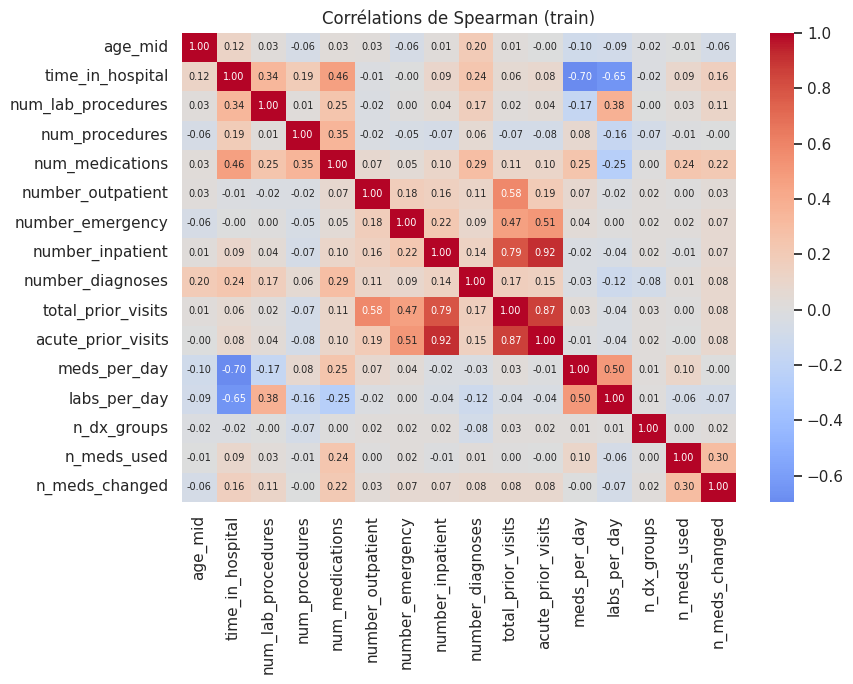

,,0
number_inpatient,acute_prior_visits,0.920
total_prior_visits,acute_prior_visits,0.867
number_inpatient,total_prior_visits,0.793


In [32]:
num_all = ['age_mid','time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_outpatient','number_emergency',
           'number_inpatient','number_diagnoses','total_prior_visits','acute_prior_visits','meds_per_day','labs_per_day',
           'n_dx_groups','n_meds_used','n_meds_changed']
trn = df[df.split=="train"]
corr = trn[num_all].corr(method="spearman")
plt.figure(figsize=(9,7)); sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size":7}); plt.title("Corrélations de Spearman (train)")
plt.tight_layout(); plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().loc[lambda s: s.abs()>0.7].sort_values(ascending=False)
pairs.round(3)

**Pourquoi Spearman et pas Pearson ?** Les variables sont asymétriques avec des valeurs extrêmes ; Spearman (basé sur les rangs) est robuste à cela.

**Constat :** trois paires dépassent 0,7 : **`acute_prior_visits` ↔ `number_inpatient` (0,92)**, `total_prior_visits` ↔ `acute_prior_visits` (0,87) et `number_inpatient` ↔ `total_prior_visits` (0,80). Cela s'explique par construction : `acute = urgences + hospitalisations`, deux des trois composantes de `total_prior_visits`. Trois colonnes répètent donc en grande partie la même information.

**Décision : on retire `acute_prior_visits`.** Elle est la plus redondante (combinaison de deux colonnes déjà présentes) et sa valeur ajoutée sur `number_inpatient` + `number_emergency` est faible. On garde `number_inpatient` (le signal le plus fort, voir sections 3.4 et 7.1), `number_emergency`, `number_outpatient` **et** le total, qui capte l'effet cumulé.
Pour le **modèle linéaire**, trop de colonnes quasi identiques rendent les coefficients instables (multicolinéarité) ; pour l'**ACP**, elles feraient peser le même facteur plusieurs fois.

### 4.4.2 Pertinence : score de lien avec la cible (méthode Filter)

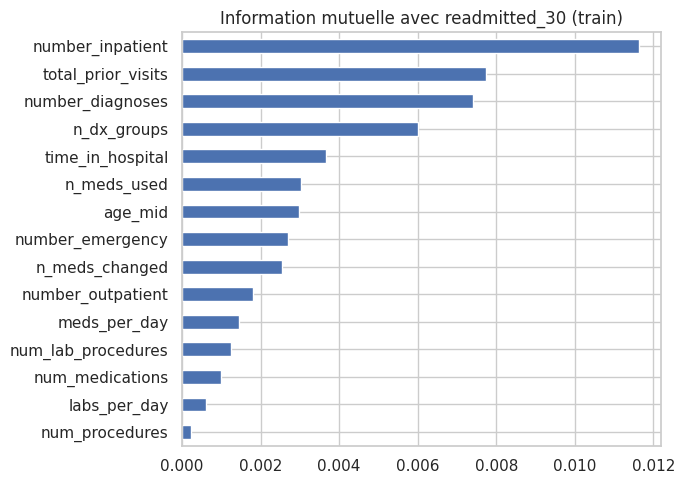

,0
number_inpatient,0.0116
total_prior_visits,0.0077
number_diagnoses,0.0074
n_dx_groups,0.0060
time_in_hospital,0.0037
age_mid,0.0030
n_meds_used,0.0030
number_emergency,0.0027
n_meds_changed,0.0025
number_outpatient,0.0018


In [33]:
from sklearn.feature_selection import mutual_info_classif
Xn = trn[[c for c in num_all if c!="acute_prior_visits"]]
mi = pd.Series(mutual_info_classif(Xn, trn.readmitted_30, random_state=RS), index=Xn.columns).sort_values()
mi.plot.barh(figsize=(7,5), title="Information mutuelle avec readmitted_30 (train)"); plt.tight_layout(); plt.show()
mi.round(4).sort_values(ascending=False)

**Pourquoi l'information mutuelle ?** Elle détecte des liens **non linéaires** (une corrélation ne voit que le linéaire). Elle est calculée sur le **train seulement**.

**Constat et décision :** les scores sont **tous très faibles** (le maximum est de 0,010), ce qui annonce un problème difficile (AUC modeste). `number_inpatient` (0,010) arrive en tête, suivie de `total_prior_visits` (0,007), puis de `n_meds_used`, `number_diagnoses` et `n_dx_groups` (≈ 0,006). **`number_outpatient` a un score nul** (0,000) pris isolément.

**On ne supprime pourtant rien d'autre**, pour trois raisons : (1) l'information mutuelle est estimée **variable par variable** et sur des valeurs si petites qu'elle est bruitée ; (2) `number_outpatient` entre dans `total_prior_visits`, qui est classée 2ᵉ, et dans le profil « Revenant » (section 5) ; (3) avec ≈ 100 colonnes pour 80 000 lignes d'entraînement le risque de sur-apprentissage reste limité, alors qu'un seuil arbitraire éliminerait des variables utiles à l'interprétation (BO3). Si le modèle final surapprenait, ce serait la première piste à explorer.

## 4.5 Étape 4 : Data Transforms (échelle, distribution, encodage)
Le cours : *Feature scaling* (standardisation, normalisation) et *Categorical encoding* (Ordinal / Label pour l'ordinal, **OneHot pour le nominal**).

### 4.5.1 Variables numériques : plafonner, redresser l'asymétrie, puis standardiser
Trois sous-étapes, **toutes apprises sur le train** :
1. **Winsorisation 1 %-99 %** (voir 4.1.5).
2. **`log1p`** pour les variables très asymétriques. `log(1+x)` « écrase » la queue de droite et accepte les zéros (contrairement à `log(x)`).
3. **Standardisation** (z = (x − μ) / σ, formule du cours) pour que toutes les variables aient la même échelle. Indispensable pour l'ACP, K-Means (distances) et la régression logistique régularisée.

In [34]:
skewed = ['time_in_hospital','num_procedures','num_medications','number_outpatient','number_emergency','number_inpatient',
          'total_prior_visits','n_meds_changed','meds_per_day','labs_per_day']
symm   = ['age_mid','num_lab_procedures','number_diagnoses','n_meds_used','n_dx_groups']
binary = ['change_flag','diabetesMed_flag','clinical_inertia','any_diabetes_dx']
trn = df[df.split=="train"]

lo = trn[skewed+symm].quantile(0.01); hi = trn[skewed+symm].quantile(0.99)       # seuils appris sur le train
w = df[skewed+symm].clip(lower=lo, upper=hi, axis=1)

sk = pd.DataFrame({"asymétrie brute": df.loc[df.split=="train", skewed+symm].skew(),
                   "après plafonnement": w[df.split=="train"].skew(),
                   "après plafonnement + log1p": pd.concat([np.log1p(w[skewed]), w[symm]],axis=1)[df.split=="train"].skew()}).round(2)
sk

,asymétrie brute,après plafonnement,après plafonnement + log1p
time_in_hospital,1.15,1.15,0.11
num_procedures,1.33,1.33,0.53
num_medications,1.32,0.98,-0.38
number_outpatient,8.42,3.35,2.43
number_emergency,25.04,3.72,2.99
number_inpatient,3.69,2.51,1.37
total_prior_visits,5.38,2.45,1.02
n_meds_changed,1.42,1.32,1.12
meds_per_day,2.21,1.83,0.43
labs_per_day,1.81,1.64,-0.49


**Lecture :** une asymétrie proche de 0 = distribution symétrique ; > 1 = forte queue à droite.
**Règle appliquée :** on applique `log1p` aux variables dont l'asymétrie brute est **> 1** (10 variables) et on laisse les autres (|asymétrie| < 0,9, soit 5 variables).
- Pour `time_in_hospital` (1,14 → **0,09**), `num_medications` (1,33 → −0,37) ou `meds_per_day` (2,23 → 0,44), plafonnement puis `log1p` donnent une distribution presque symétrique.
- Pour les **compteurs d'historique**, `log1p` **améliore mais ne résout pas** : `number_emergency` passe de 24,7 à 3,0 (après plafonnement + log) et `number_outpatient` de 8,6 à 2,4. La raison est qu'une grande majorité de patients vaut exactement 0 : **aucune transformation monotone ne peut étaler un pic à zéro**. On accepte cette limite ; elle est sans gravité pour les arbres, et acceptable pour la régression.
- Les 5 variables de `symm` (âge, examens, diagnostics, nb de médicaments, nb de groupes de diagnostics) sont **déjà proches de la symétrie** : leur appliquer `log1p` n'apporterait rien et rendrait l'interprétation plus difficile.
- **Les indicateurs 0/1 ne sont ni transformés ni standardisés** : ils sont déjà interprétables et sur une échelle comparable.

### 4.5.2 Variables catégorielles : One-Hot (nominales), avec regroupement des modalités rares
**Pourquoi One-Hot et pas Label/Ordinal ?** Aucune de ces variables n'a d'ordre naturel (une race, une spécialité, un service d'admission…). Un `LabelEncoder` imposerait un faux ordre (`Emergency=0 < Urgent=1 < Elective=2`) que la régression logistique et K-Means interpréteraient comme une distance. L'âge, lui, est ordinal : il est déjà traité en numérique (`age_mid`).

**Pourquoi `min_frequency=0.01` ?** Les modalités qui représentent < 1 % des séjours (ex. race `Asian`, spécialité `Pulmonology`, sortie `Left AMA`) sont **regroupées dans une colonne « infrequent »**. Cela évite des colonnes quasi vides (instables, sur-apprentissage) tout en gardant l'information « autre ». `handle_unknown="infrequent_if_exist"` gère proprement une modalité jamais vue au train.

In [35]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
cats = ['race','gender','admission_type','admission_source','discharge_dest','medical_specialty',
        'diag1_group','diag2_group','diag3_group','insulin','metformin','A1C_status','glu_status']

# numériques
num_tr = np.log1p(w[skewed]).join(w[symm])
sc = StandardScaler().fit(num_tr[df.split=="train"])
X_num = pd.DataFrame(sc.transform(num_tr), columns=num_tr.columns, index=df.index)

# catégorielles
ohe = OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist", sparse_output=False).fit(df.loc[df.split=="train", cats])
X_cat = pd.DataFrame(ohe.transform(df[cats]), columns=ohe.get_feature_names_out(cats), index=df.index)

prepared = pd.concat([df[["patient_nbr"]], X_num, df[binary], X_cat, df[["split","readmitted_30"]]], axis=1)
print("Dimensions finales :", prepared.shape, "| colonnes encodées :", X_cat.shape[1])
print("Colonnes 'infrequent' créées :", [c for c in X_cat.columns if "infrequent" in c])

Dimensions finales : (99340, 102) | colonnes encodées : 80
Colonnes 'infrequent' créées : ['race_infrequent_sklearn', 'discharge_dest_infrequent_sklearn', 'medical_specialty_infrequent_sklearn', 'diag1_group_infrequent_sklearn', 'diag2_group_infrequent_sklearn', 'metformin_infrequent_sklearn']


**Constat :** on passe de ≈ 50 colonnes brutes (dont des codes et 23 médicaments) à **102 colonnes** numériques propres. On vérifie maintenant que la moyenne est ≈ 0 et l'écart-type ≈ 1 **sur le train** (preuve que la standardisation a été apprise là) ; sur le test, ils sont proches mais pas exactement 0 et 1, ce qui est **normal et souhaitable** : le test ne doit pas influencer les paramètres.

In [36]:
chk = pd.DataFrame({"moyenne train": prepared.loc[prepared.split=="train", X_num.columns].mean(),
                    "écart-type train": prepared.loc[prepared.split=="train", X_num.columns].std(),
                    "moyenne test": prepared.loc[prepared.split=="test", X_num.columns].mean()}).round(3)
chk.head(8)

,moyenne train,écart-type train,moyenne test
time_in_hospital,0.0,1.0,-0.002
num_procedures,0.0,1.0,0.012
num_medications,0.0,1.0,0.006
number_outpatient,-0.0,1.0,-0.008
number_emergency,-0.0,1.0,0.011
number_inpatient,-0.0,1.0,0.030
total_prior_visits,0.0,1.0,0.015
n_meds_changed,0.0,1.0,0.003


### 4.5.3 Construction des fichiers livrés et contrôles de qualité
On construit le fichier **lisible** `clean` (population de modélisation, même ordre de lignes que `prepared`) et `clean_all` (= `clean` + séjours décès / hospice, marqués `split = excluded`). On vérifie ensuite quelques propriétés d'un pipeline sain.

In [37]:
clean_cols = ["encounter_id","patient_nbr","readmitted_30","race","gender","age_mid","admission_type","admission_source","discharge_dest",
              "medical_specialty","time_in_hospital","num_lab_procedures","num_procedures","num_medications","number_diagnoses",
              "number_outpatient","number_emergency","number_inpatient","total_prior_visits","acute_prior_visits","meds_per_day","labs_per_day",
              "diag1_group","diag2_group","diag3_group","n_dx_groups","any_diabetes_dx","n_meds_used","n_meds_changed","insulin","metformin",
              "change_flag","diabetesMed_flag","A1C_status","glu_status","clinical_inertia","split"]
clean = df[clean_cols].copy()                                  # population de modélisation
prepared = prepared.drop(columns=[c for c in ["acute_prior_visits"] if c in prepared.columns])
clean_dead = dead_all[clean_cols].copy(); clean_dead["split"] = "excluded"
clean_all = pd.concat([clean, clean_dead], ignore_index=True)    # tout l'hôpital, pour le tableau de bord

tr_p = set(prepared.patient_nbr[prepared.split=="train"]); te_p = set(prepared.patient_nbr[prepared.split=="test"])
checks = {
    "aucune valeur manquante dans prepared": int(prepared.isna().sum().sum()) == 0,
    "aucun patient commun entre train et test": len(tr_p & te_p) == 0,
    "clean et prepared alignés (même nombre de lignes)": len(clean) == len(prepared),
    "aucun décès / hospice dans la population de modélisation": not (clean.discharge_dest == "Deceased / hospice").any(),
    "aucune ligne perdue dans clean_all": len(clean_all) == len(clean) + len(dead_all),
}
for k, v in checks.items(): print("OK  " if v else "KO  ", k)
print("clean_all :", clean_all.shape, "| clean :", clean.shape, "| prepared :", prepared.shape)

OK   aucune valeur manquante dans prepared
OK   aucun patient commun entre train et test
OK   clean et prepared alignés (même nombre de lignes)
OK   aucun décès / hospice dans la population de modélisation
OK   aucune ligne perdue dans clean_all
clean_all : (101763, 37) | clean : (99340, 37) | prepared : (99340, 102)


Si tous les contrôles affichent `OK`, les données utilisées dans les sections 5 à 7 sont **saines** : complètes, sans fuite entre train et test, et sans séjours décès / hospice.

## 4.6 Étape 5 : Dimensionality Reduction — l'ACP pas à pas
Le cours donne les étapes : **(1) standardiser, (2) matrice de covariance puis valeurs/vecteurs propres, (3) trier les valeurs propres, (4) former le vecteur de caractéristiques, (5) projeter Z = X·V, (6) reconstruire**. On les refait **à la main**, puis on compare à `scikit-learn` pour prouver qu'on a bien compris la méthode.

**Périmètre :** l'ACP s'applique aux **13 variables numériques cliniques** déjà standardisées (pas aux colonnes 0/1 du One-Hot, dont la géométrie n'a pas de sens pour l'ACP classique).

In [38]:
pca_vars = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_diagnoses','number_outpatient',
            'number_emergency','number_inpatient','n_meds_used','n_meds_changed','age_mid','n_dx_groups','total_prior_visits']
X = prepared[pca_vars].values                       # étape 1 : déjà centré-réduit (sur le train)
X = (X - X.mean(0)) / X.std(0)                      # re-centrage exact sur toute la population analysée

# étape 2 : covariance (= corrélation car variables réduites) et décomposition propre
Cmat = np.cov(X, rowvar=False)
eigval, eigvec = np.linalg.eigh(Cmat)

# étape 3 : tri décroissant
order = np.argsort(eigval)[::-1]; eigval, eigvec = eigval[order], eigvec[:, order]
# le signe d'un vecteur propre est arbitraire : on impose que la plus forte contribution de chaque axe soit positive (lecture plus simple)
for j in range(eigvec.shape[1]):
    if eigvec[np.abs(eigvec[:, j]).argmax(), j] < 0: eigvec[:, j] *= -1

# étape 5 : projection Z = X V
Z_manual = X @ eigvec

from sklearn.decomposition import PCA
pca = PCA().fit(X)
print("Valeurs propres identiques à scikit-learn :", np.allclose(eigval, pca.explained_variance_))
print("Projection identique (au signe près) :", np.allclose(np.abs(Z_manual), np.abs(pca.transform(X)), atol=1e-6))
print("Somme des valeurs propres (variance totale) =", round(eigval.sum(),3), "= nombre de variables (", len(pca_vars), ")")

Valeurs propres identiques à scikit-learn : True
Projection identique (au signe près) : True
Somme des valeurs propres (variance totale) = 13.0 = nombre de variables ( 13 )


**Constat :** nos valeurs propres coïncident avec celles de `scikit-learn` : la décomposition manuelle du cours est correcte.
Comme les variables sont **réduites** (variance 1), la **variance totale = nombre de variables = 13** ; c'est ce qui rend la règle de Kaiser (valeur propre > 1 = « plus informatif qu'une variable seule ») directement applicable.

### 4.6.1 Combien d'axes garder ? (méthodes 3, 4 et 5 du cours)

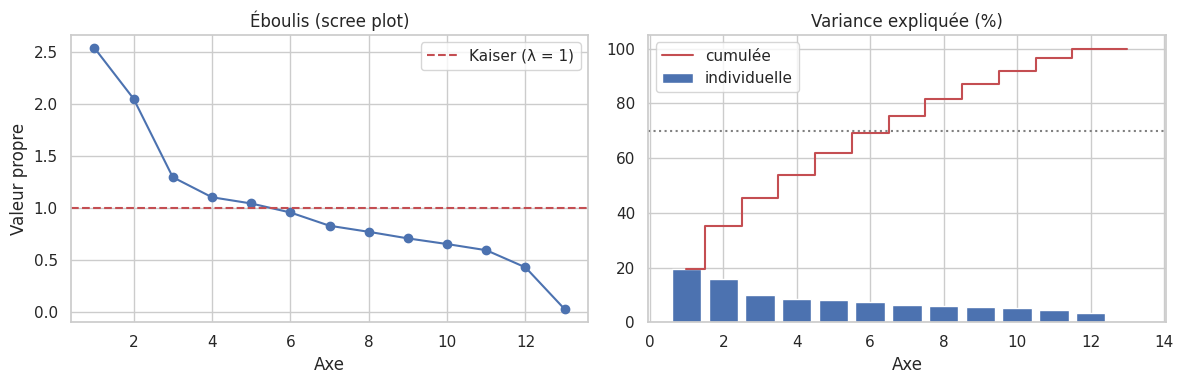

Axes avec λ > 1 (Kaiser) : 5
Variance cumulée : {1: np.float64(19.5), 2: np.float64(35.3), 3: np.float64(45.3), 4: np.float64(53.7), 5: np.float64(61.8), 6: np.float64(69.1), 7: np.float64(75.5)}


In [39]:
ev_ratio = eigval/eigval.sum()
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(range(1,14), eigval, "o-"); ax[0].axhline(1, c="r", ls="--", label="Kaiser (λ = 1)"); ax[0].set(title="Éboulis (scree plot)", xlabel="Axe", ylabel="Valeur propre"); ax[0].legend()
ax[1].bar(range(1,14), ev_ratio*100, label="individuelle"); ax[1].step(range(1,14), ev_ratio.cumsum()*100, c="r", where="mid", label="cumulée")
ax[1].axhline(70, c="grey", ls=":"); ax[1].set(title="Variance expliquée (%)", xlabel="Axe"); ax[1].legend()
plt.tight_layout(); plt.show()
print("Axes avec λ > 1 (Kaiser) :", int((eigval>1).sum()))
print("Variance cumulée :", dict(zip(range(1,8), (ev_ratio.cumsum()[:7]*100).round(1))))

**Les trois critères donnent des réponses **différentes**, et c'est instructif :**

| Critère (cours) | Réponse |
|---|---|
| **Kaiser** (λ > 1) | 5 axes (valeurs propres > 1) |
| **Coude** (scree plot) | à repérer sur le graphique : la décroissance ralentit à partir de l'axe 4 |
| **Variance cumulée** | ≈ 54 % avec 4 axes ; il faut ≈ 7 axes pour dépasser 70 % |

**Décision : on retient 4 axes pour le clustering (section 5).** Kaiser est souvent trop généreux sur de nombreuses variables ; le coude est autour de 4 ; et 4 axes sont **interprétables** (voir le cercle). **Limite assumée : 54 % de variance seulement.** Les données hospitalières sont « diffuses » : il n'existe pas 2 ou 3 axes qui résument tout. On le présente honnêtement plutôt que de forcer un seuil à 80 %.

### 4.6.2 Interpréter les axes : cercle des corrélations (cours : « understanding of variables »)

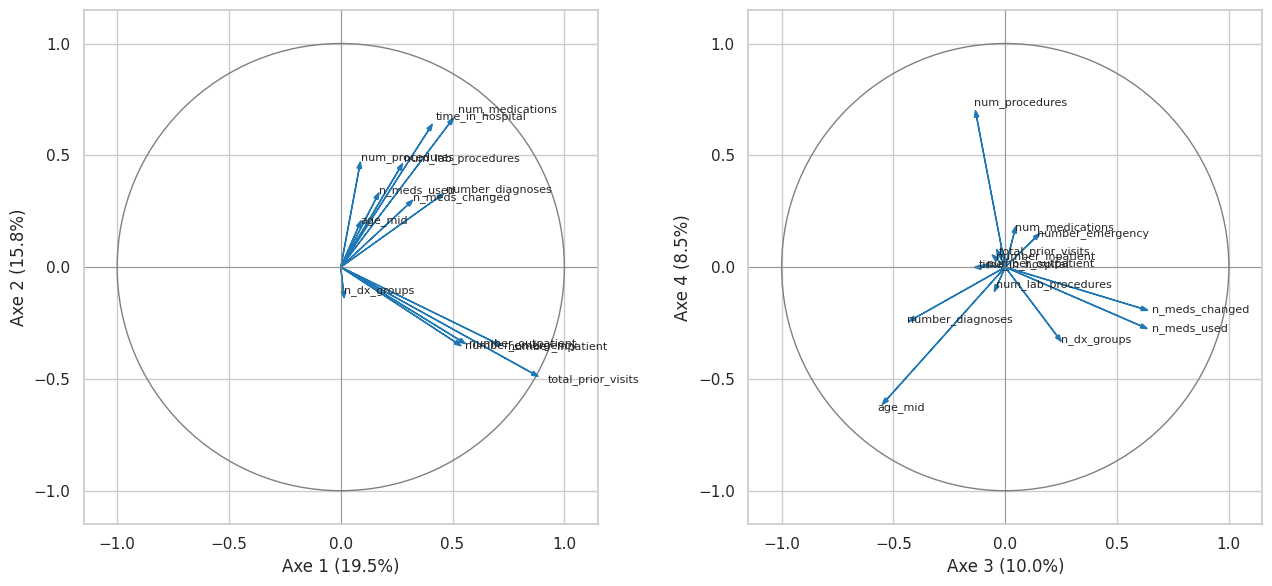

,Axe 1,Axe 2,Axe 3,Axe 4
time_in_hospital,0.39,0.61,-0.11,-0.00
num_lab_procedures,0.26,0.44,-0.04,-0.08
num_procedures,0.08,0.44,-0.13,0.67
num_medications,0.49,0.64,0.04,0.15
number_diagnoses,0.44,0.31,-0.41,-0.23
number_outpatient,0.53,-0.33,-0.07,0.01
number_emergency,0.51,-0.34,0.13,0.13
number_inpatient,0.69,-0.34,-0.04,0.03
n_meds_used,0.16,0.31,0.61,-0.26
n_meds_changed,0.30,0.28,0.61,-0.18


In [40]:
loads = pd.DataFrame(eigvec[:, :4] * np.sqrt(eigval[:4]), index=pca_vars, columns=[f"Axe {i+1}" for i in range(4)])
fig, axs = plt.subplots(1,2, figsize=(13,6))
for a,(i,j) in zip(axs, [(0,1),(2,3)]):
    a.add_patch(plt.Circle((0,0),1,fill=False,color="grey"))
    for v in pca_vars:
        x,y = loads.loc[v].iloc[i], loads.loc[v].iloc[j]
        a.arrow(0,0,x,y,head_width=.02,color="tab:blue"); a.text(x*1.08,y*1.08,v,fontsize=8)
    a.axhline(0,c="grey",lw=.5); a.axvline(0,c="grey",lw=.5); a.set_aspect("equal"); a.set(xlim=(-1.15,1.15),ylim=(-1.15,1.15),
        xlabel=f"Axe {i+1} ({ev_ratio[i]*100:.1f}%)", ylabel=f"Axe {j+1} ({ev_ratio[j]*100:.1f}%)")
plt.tight_layout(); plt.show()
loads.round(2)

**Lecture (règles du cours : plus la flèche est proche du bord du cercle, mieux la variable est représentée ; l'angle entre deux flèches = leur corrélation) :**
*(Le signe d'un axe est arbitraire en ACP : on l'a orienté pour que la plus forte contribution soit positive.)*
- **Axe 1 : « habitué du système de soins »** : `total_prior_visits` (0,86), `number_inpatient` (0,69), consultations et urgences antérieures.
- **Axe 2 : « intensité du séjour »** : nombre de médicaments (0,64), durée (0,61), examens, procédures ; il s'oppose aux visites antérieures (≈ −0,3 à −0,5), c'est-à-dire que les patients « à gros historique » ont souvent des séjours plus légers.
- **Axe 3 : « complexité du traitement »** : `n_meds_used` et `n_meds_changed` (≈ 0,61).
- **Axe 4** : procédures, opposées à l'âge.
- `total_prior_visits` et `number_inpatient` pointent dans la même direction (angle faible) : **corrélées**, comme annoncé en 4.4.1.

### 4.6.3 Carte des individus (cours : « Individual factor map »)

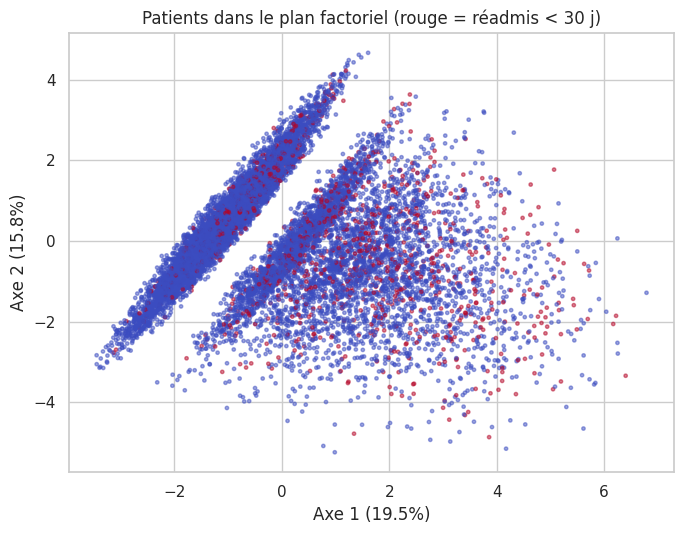

Position moyenne sur l'axe 1 -> non réadmis : -0.08 | réadmis : 0.64


In [41]:
rng = np.random.RandomState(RS); idx = rng.choice(len(Z_manual), 12000, replace=False)
fig, ax = plt.subplots(figsize=(7,5.5))
sc_ = ax.scatter(Z_manual[idx,0], Z_manual[idx,1], c=prepared.readmitted_30.values[idx], cmap="coolwarm", s=6, alpha=.5)
ax.set(xlabel=f"Axe 1 ({ev_ratio[0]*100:.1f}%)", ylabel=f"Axe 2 ({ev_ratio[1]*100:.1f}%)", title="Patients dans le plan factoriel (rouge = réadmis < 30 j)")
plt.tight_layout(); plt.show()
m = pd.Series(Z_manual[:,0]).groupby(prepared.readmitted_30.values).mean().round(2)
print("Position moyenne sur l'axe 1 -> non réadmis :", m[0], "| réadmis :", m[1])

**Constat :** les patients réadmis (rouge) ne forment **pas un groupe séparé** : on observe un **nuage chevauchant**, avec seulement une dérive vers la droite sur l'axe 1 (l'historique de soins) : position moyenne ≈ +0,64 pour les réadmis contre −0,08 pour les autres, sur des axes dont l'écart-type est d'environ 1,6. Cela annonce visuellement ce que les sections 6 et 7 confirmeront par les chiffres : **la réadmission est difficile à prédire** (AUC ≈ 0,66). L'ACP est ici un outil de **compréhension et de segmentation** (personas), pas un moyen de rendre la prédiction facile.

## 4.7 Sauvegarde (Data storage)

In [42]:
clean_all.to_csv("diabetes_clean.csv", index=False)
prepared.to_csv("diabetes_prepared.csv", index=False)
print("Enregistrés :", clean_all.shape, prepared.shape)
print("Taux de valeurs manquantes dans prepared :", int(prepared.isna().sum().sum()))

Enregistrés : (101763, 37) (99340, 102)
Taux de valeurs manquantes dans prepared : 0


## 4.8 Résumé des décisions de préparation

| Étape (cours) | Décision | Justification principale |
|---|---|---|
| Cleaning · population | retirer 3 genres invalides ; **identifier puis exclure de la modélisation** les décès/hospice (2 423), conservés dans `clean` et le tableau de bord | cible = 0 par construction, rien à apprendre ; effet mesuré en 7.5 |
| Cleaning · doublons | aucun | vérifié par `duplicated()` |
| Cleaning · colonnes | retirer `weight`, `payer_code`, `examide`, `citoglipton` | 97 % / 40 % manquants, administratif, variance nulle |
| Cleaning · manquants | **marquer** (`Missing`, `Unknown`, `NotTested`) plutôt qu'imputer | l'absence est informative ; race = variable à auditer |
| Cleaning · outliers | **plafonner 1 %-99 %** (train), ne rien supprimer | vraies observations, ce sont les patients les plus à risque |
| Feature engineering | 9 groupes ICD-9, catégories lisibles, ≈ 15 variables créées dont `clinical_inertia` (non prédictive seule) | réduire la dimension, apporter du sens clinique |
| Découpage | par patient, stratifié, **avant** toute statistique apprise | évite la fuite entre séjours d'un même patient |
| Feature selection | retirer `acute_prior_visits` (redondante) ; garder le reste | multicolinéarité ; scores MI faibles mais non nuls |
| Transforms · numériques | winsorisation + `log1p` (10 variables asymétriques) + standardisation | stabilise ACP, K-Means, régression |
| Transforms · catégories | One-Hot, `min_frequency=0.01` | pas d'ordre naturel ; évite colonnes quasi vides |
| Réduction · ACP | 4 axes (≈ 54 % de variance) | coude + interprétabilité ; limite assumée |

**Suite :** les sections 5 à 7 utilisent ces données pour les personas, le radar de sortie, les signaux faibles et l'audit d'équité.

In [43]:
# Ces deux objets (clean, prepared) sont réutilisés directement ci-dessous ; les fichiers sont déjà sauvegardés en 4.7.
print("clean    :", clean.shape, "(lisible, population de modélisation : sert à interpréter)")
print("prepared :", prepared.shape, "(encodé et standardisé : sert à modéliser)")

clean    : (99340, 37) (lisible, population de modélisation : sert à interpréter)
prepared : (99340, 102) (encodé et standardisé : sert à modéliser)
